## 1. Configuración

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette('Set2')
%matplotlib inline

print("✓ Configuración completada")

✓ Configuración completada


## 2. Carga de Datos

In [2]:
# Cargar datos con clusters
data_path = Path.cwd().parent / 'data' / 'clustered_data.csv'
df = pd.read_csv(data_path)

print(f"✓ Datos cargados: {df.shape}")
print(f"\nColumnas de clustering:")
print(f"  - Cluster_KMeans: {df['Cluster_KMeans'].nunique()} clusters")
print(f"  - Cluster_DBSCAN: {df['Cluster_DBSCAN'].nunique() - 1} clusters + ruido")

✓ Datos cargados: (2881, 57)

Columnas de clustering:
  - Cluster_KMeans: 2 clusters
  - Cluster_DBSCAN: 3 clusters + ruido


## 3. Perfiles Operativos - K-means

In [3]:
# Definir nombres descriptivos para clusters K-means
kmeans_profiles = {
    0: 'Alta Carga Operativa',
    1: 'Baja Carga / Reposo'
}

df['Perfil_KMeans'] = df['Cluster_KMeans'].map(kmeans_profiles)

print("="*70)
print("PERFILES OPERATIVOS - K-MEANS")
print("="*70)

for cluster_id, profile_name in kmeans_profiles.items():
    cluster_data = df[df['Cluster_KMeans'] == cluster_id]
    n = len(cluster_data)
    pct = n / len(df) * 100
    
    print(f"\n{'='*70}")
    print(f"{profile_name.upper()} (Cluster {cluster_id})")
    print(f"Observaciones: {n:,} ({pct:.1f}%)")
    print(f"{'='*70}")
    
    print(f"\nConsumo:")
    print(f"  KWHD medio: {cluster_data['KWHD'].mean():.2f} kWh")
    print(f"  Rango: {cluster_data['KWHD'].min():.2f} - {cluster_data['KWHD'].max():.2f} kWh")
    
    print(f"\nCalidad Eléctrica:")
    print(f"  Factor de potencia: {cluster_data['FACTOR_POTENCIA'].mean():.3f}")
    print(f"  THD corriente promedio: {cluster_data['THD_CORRIENTE_PROMEDIO'].mean():.3f}")
    print(f"  Desbalance corriente: {cluster_data['DESBALANCE_CORRIENTE'].mean():.3f}")
    
    print(f"\nPerfil Temporal:")
    hora_pico = cluster_data['HORA'].mode()[0]
    print(f"  Hora pico: {hora_pico}:00")
    print(f"  Hora promedio: {cluster_data['HORA'].mean():.1f}")

PERFILES OPERATIVOS - K-MEANS

ALTA CARGA OPERATIVA (Cluster 0)
Observaciones: 1,508 (52.3%)

Consumo:
  KWHD medio: 21.03 kWh
  Rango: 9.84 - 36.66 kWh

Calidad Eléctrica:
  Factor de potencia: 0.984
  THD corriente promedio: 0.161
  Desbalance corriente: 0.161

Perfil Temporal:
  Hora pico: 8:00
  Hora promedio: 11.8

BAJA CARGA / REPOSO (Cluster 1)
Observaciones: 1,373 (47.7%)

Consumo:
  KWHD medio: 6.96 kWh
  Rango: 0.48 - 18.66 kWh

Calidad Eléctrica:
  Factor de potencia: 0.992
  THD corriente promedio: 0.356
  Desbalance corriente: 0.187

Perfil Temporal:
  Hora pico: 0:00
  Hora promedio: 11.2


## 4. Perfiles Operativos - DBSCAN

In [4]:
# Definir nombres descriptivos para clusters DBSCAN
dbscan_profiles = {
    -1: 'Anomalías / Transitorios',
    0: 'Pico Máximo de Carga',
    1: 'Operación Mínima',
    2: 'Carga Media Estable'
}

df['Perfil_DBSCAN'] = df['Cluster_DBSCAN'].map(dbscan_profiles)

print("="*70)
print("PERFILES OPERATIVOS - DBSCAN")
print("="*70)

for cluster_id in sorted(df['Cluster_DBSCAN'].unique()):
    if cluster_id == -1:
        continue  # Procesaremos anomalías al final
    
    profile_name = dbscan_profiles[cluster_id]
    cluster_data = df[df['Cluster_DBSCAN'] == cluster_id]
    n = len(cluster_data)
    pct = n / len(df) * 100
    
    print(f"\n{'='*70}")
    print(f"{profile_name.upper()} (Cluster {cluster_id})")
    print(f"Observaciones: {n:,} ({pct:.1f}%)")
    print(f"{'='*70}")
    
    print(f"\nConsumo:")
    print(f"  KWHD medio: {cluster_data['KWHD'].mean():.2f} kWh")
    print(f"  Desviación estándar: {cluster_data['KWHD'].std():.2f} kWh")
    
    print(f"\nCalidad Eléctrica:")
    print(f"  Factor de potencia: {cluster_data['FACTOR_POTENCIA'].mean():.3f}")
    print(f"  THD corriente: {cluster_data['THD_CORRIENTE_PROMEDIO'].mean():.3f}")

# Anomalías
if -1 in df['Cluster_DBSCAN'].values:
    anomalies = df[df['Cluster_DBSCAN'] == -1]
    print(f"\n{'='*70}")
    print(f"ANOMALÍAS / TRANSITORIOS")
    print(f"Observaciones: {len(anomalies):,} ({len(anomalies)/len(df)*100:.1f}%)")
    print(f"{'='*70}")
    print(f"\nPatrones atípicos que requieren investigación individual.")
    print(f"Rango de consumo: {anomalies['KWHD'].min():.2f} - {anomalies['KWHD'].max():.2f} kWh")

PERFILES OPERATIVOS - DBSCAN

PICO MÁXIMO DE CARGA (Cluster 0)
Observaciones: 326 (11.3%)

Consumo:
  KWHD medio: 22.39 kWh
  Desviación estándar: 1.84 kWh

Calidad Eléctrica:
  Factor de potencia: 0.992
  THD corriente: 0.160

OPERACIÓN MÍNIMA (Cluster 1)
Observaciones: 1,118 (38.8%)

Consumo:
  KWHD medio: 6.42 kWh
  Desviación estándar: 1.06 kWh

Calidad Eléctrica:
  Factor de potencia: 0.998
  THD corriente: 0.362

CARGA MEDIA ESTABLE (Cluster 2)
Observaciones: 506 (17.6%)

Consumo:
  KWHD medio: 17.71 kWh
  Desviación estándar: 1.78 kWh

Calidad Eléctrica:
  Factor de potencia: 0.987
  THD corriente: 0.163

ANOMALÍAS / TRANSITORIOS
Observaciones: 931 (32.3%)

Patrones atípicos que requieren investigación individual.
Rango de consumo: 0.48 - 36.66 kWh


## 5. Visualización: Distribución de Perfiles

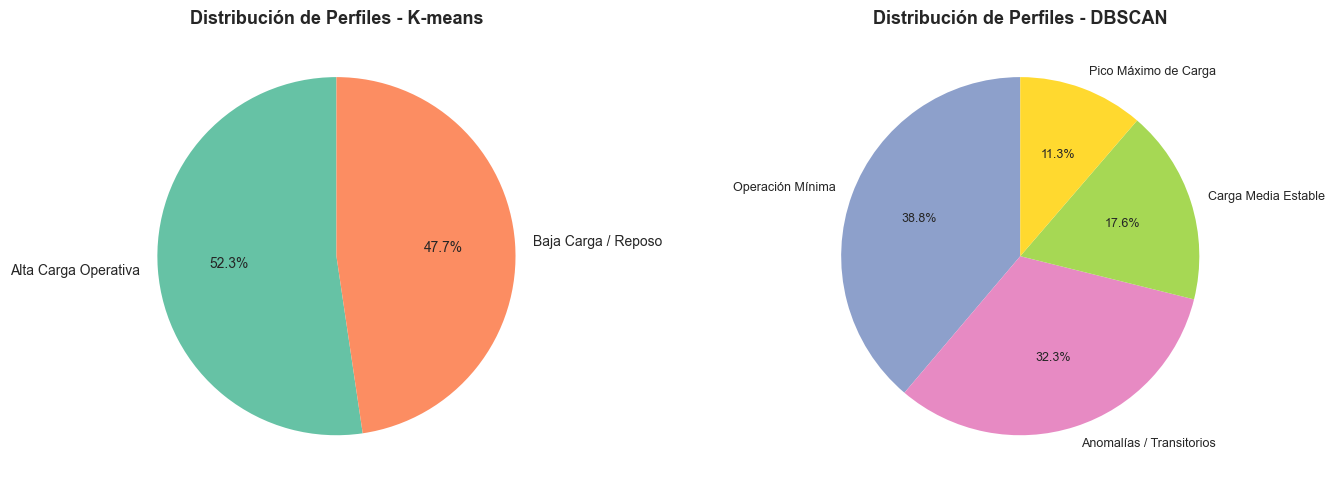

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# K-means
kmeans_counts = df['Perfil_KMeans'].value_counts()
colors_km = ['#66c2a5', '#fc8d62']
axes[0].pie(kmeans_counts.values, labels=kmeans_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors_km, textprops={'fontsize': 10})
axes[0].set_title('Distribución de Perfiles - K-means', fontsize=13, fontweight='bold')

# DBSCAN
dbscan_counts = df['Perfil_DBSCAN'].value_counts()
colors_db = ['#8da0cb', '#e78ac3', '#a6d854', '#ffd92f']
axes[1].pie(dbscan_counts.values, labels=dbscan_counts.index, autopct='%1.1f%%',
           startangle=90, colors=colors_db, textprops={'fontsize': 9})
axes[1].set_title('Distribución de Perfiles - DBSCAN', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/perfiles_distribucion.png', dpi=300, bbox_inches='tight')
plt.show()

## 6. Visualización: Patrón Temporal de Consumo

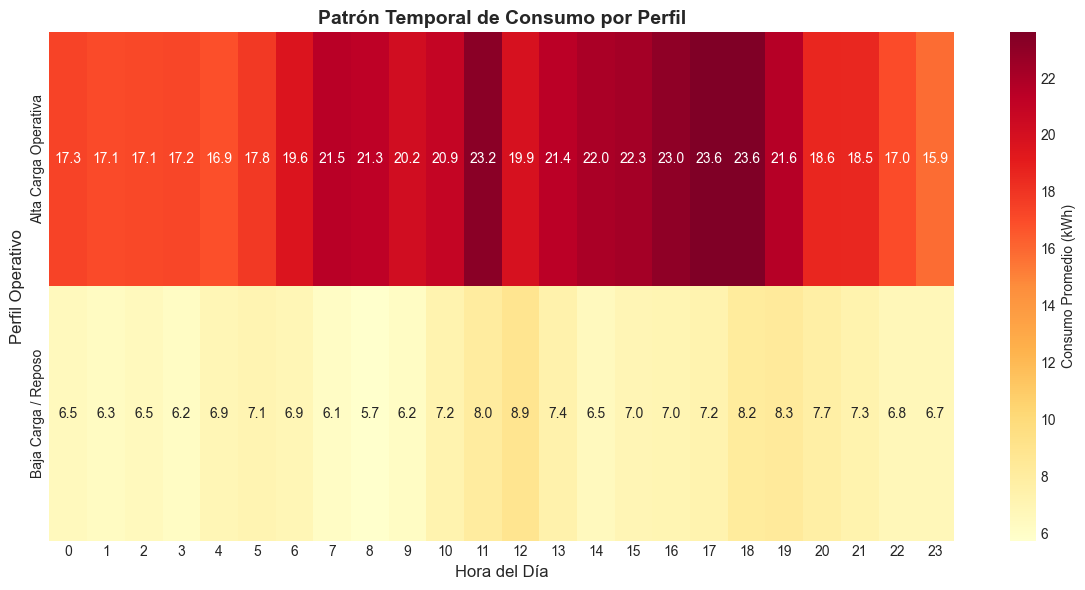

In [6]:
# Heatmap de consumo por hora y perfil K-means
pivot_data = df.groupby(['HORA', 'Perfil_KMeans'])['KWHD'].mean().reset_index()
pivot_table = pivot_data.pivot(index='HORA', columns='Perfil_KMeans', values='KWHD')

fig, ax = plt.subplots(figsize=(12, 6))
sns.heatmap(pivot_table.T, annot=True, fmt='.1f', cmap='YlOrRd', 
            cbar_kws={'label': 'Consumo Promedio (kWh)'}, ax=ax)
ax.set_xlabel('Hora del Día', fontsize=12)
ax.set_ylabel('Perfil Operativo', fontsize=12)
ax.set_title('Patrón Temporal de Consumo por Perfil', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../images/patron_temporal_perfiles.png', dpi=300, bbox_inches='tight')
plt.show()

## 7. Visualización: Comparación de Calidad Eléctrica

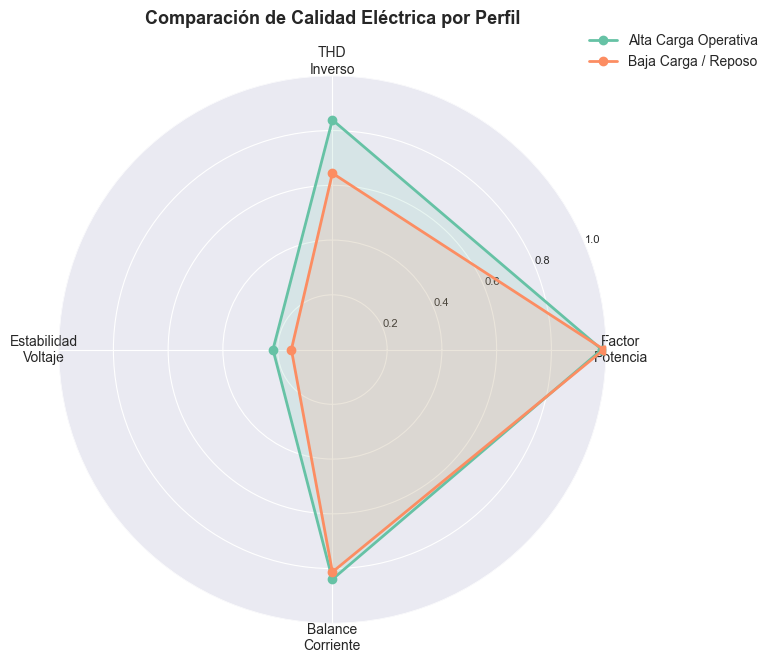

In [7]:
# Radar chart comparando perfiles K-means
from math import pi

categories = ['Factor\nPotencia', 'THD\nInverso', 'Estabilidad\nVoltaje', 'Balance\nCorriente']
N = len(categories)
angles = [n / float(N) * 2 * pi for n in range(N)]
angles += angles[:1]

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(projection='polar'))

for cluster_id, profile_name in kmeans_profiles.items():
    cluster_data = df[df['Cluster_KMeans'] == cluster_id]
    
    # Normalizar métricas [0-1]
    values = [
        cluster_data['FACTOR_POTENCIA'].mean(),  # Ya en [0-1]
        1 - cluster_data['THD_CORRIENTE_PROMEDIO'].mean(),  # Invertir THD
        1 - (cluster_data['VOLTAJE_PROM'].std() / 100),  # Normalizar estabilidad
        1 - cluster_data['DESBALANCE_CORRIENTE'].mean()  # Invertir desbalance
    ]
    values += values[:1]
    
    ax.plot(angles, values, 'o-', linewidth=2, label=profile_name)
    ax.fill(angles, values, alpha=0.15)

ax.set_xticks(angles[:-1])
ax.set_xticklabels(categories, size=10)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], size=8)
ax.grid(True)
ax.legend(loc='upper right', bbox_to_anchor=(1.3, 1.1))
ax.set_title('Comparación de Calidad Eléctrica por Perfil', y=1.08, fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('../images/radar_calidad_electrica.png', dpi=300, bbox_inches='tight')
plt.show()

## 8. Insights Accionables

In [8]:
print("="*80)
print("INSIGHTS ACCIONABLES Y RECOMENDACIONES")
print("="*80)

print("\n1. OPTIMIZACIÓN DE CALIDAD ELÉCTRICA")
print("-" * 80)
low_pf = df[df['FACTOR_POTENCIA'] < 0.95]
print(f"   • {len(low_pf)} observaciones ({len(low_pf)/len(df)*100:.1f}%) con FP < 0.95")
print(f"   • Recomendación: Instalar bancos de capacitores para corrección")
print(f"   • Ahorro estimado en penalizaciones: Aplica tarifa según regulación local")

print("\n2. GESTIÓN DE DISTORSIÓN ARMÓNICA (THD)")
print("-" * 80)
high_thd = df[df['THD_CORRIENTE_PROMEDIO'] > 0.3]
print(f"   • {len(high_thd)} observaciones ({len(high_thd)/len(df)*100:.1f}%) con THD > 30%")
print(f"   • Mayormente en perfil: {high_thd['Perfil_KMeans'].mode()[0]}")
print(f"   • Recomendación: Evaluar filtros armónicos o equipos de compensación")

print("\n3. DESBALANCE DE FASES")
print("-" * 80)
unbalanced = df[df['DESBALANCE_CORRIENTE'] > 0.2]
print(f"   • {len(unbalanced)} observaciones ({len(unbalanced)/len(df)*100:.1f}%) con desbalance > 20%")
print(f"   • Recomendación: Redistribuir cargas entre fases para equilibrio")
print(f"   • Beneficio: Reducción de pérdidas en neutro, mayor eficiencia")

print("\n4. OPTIMIZACIÓN DE DEMANDA Y TARIFAS")
print("-" * 80)
print(f"   • Consumo pico (Cluster 0): {df[df['Cluster_KMeans']==0]['KWHD'].mean():.2f} kWh")
print(f"   • Horario pico: {df[df['Cluster_KMeans']==0]['HORA'].mode()[0]}:00")
print(f"   • Recomendación: Evaluar gestión de demanda en horarios pico")
print(f"   • Oportunidad: Diferir cargas no críticas a horarios valle")

print("\n5. INVESTIGACIÓN DE ANOMALÍAS")
print("-" * 80)
if -1 in df['Cluster_DBSCAN'].values:
    anomalies = df[df['Cluster_DBSCAN'] == -1]
    print(f"   • {len(anomalies)} eventos anómalos detectados ({len(anomalies)/len(df)*100:.1f}%)")
    print(f"   • Rango de consumo atípico: {anomalies['KWHD'].min():.2f} - {anomalies['KWHD'].max():.2f} kWh")
    print(f"   • Recomendación: Auditoría detallada de estos eventos")
    print(f"   • Posibles causas: Arranques, transitorios, equipos defectuosos")

INSIGHTS ACCIONABLES Y RECOMENDACIONES

1. OPTIMIZACIÓN DE CALIDAD ELÉCTRICA
--------------------------------------------------------------------------------
   • 51 observaciones (1.8%) con FP < 0.95
   • Recomendación: Instalar bancos de capacitores para corrección
   • Ahorro estimado en penalizaciones: Aplica tarifa según regulación local

2. GESTIÓN DE DISTORSIÓN ARMÓNICA (THD)
--------------------------------------------------------------------------------
   • 1111 observaciones (38.6%) con THD > 30%
   • Mayormente en perfil: Baja Carga / Reposo
   • Recomendación: Evaluar filtros armónicos o equipos de compensación

3. DESBALANCE DE FASES
--------------------------------------------------------------------------------
   • 782 observaciones (27.1%) con desbalance > 20%
   • Recomendación: Redistribuir cargas entre fases para equilibrio
   • Beneficio: Reducción de pérdidas en neutro, mayor eficiencia

4. OPTIMIZACIÓN DE DEMANDA Y TARIFAS
---------------------------------------

## 9. Limitaciones del Estudio

In [9]:
print("="*80)
print("LIMITACIONES Y CONSIDERACIONES")
print("="*80)

print("\n1. ALCANCE TEMPORAL")
print("-" * 80)
print("   • Datos de un solo mes (octubre 2025)")
print("   • No captura variaciones estacionales")
print("   • Recomendación: Validar con datos de 12 meses")

print("\n2. ALCANCE DE CLIENTE")
print("-" * 80)
print("   • Análisis de un único cliente industrial")
print("   • Patrones no generalizables a otros sectores")
print("   • Enfoque: Profundidad sobre amplitud")

print("\n3. VARIABLES CONTEXTUALES NO INCLUIDAS")
print("-" * 80)
print("   • Temperatura, clima, producción, turnos laborales")
print("   • Variables externas podrían explicar algunos patrones")
print("   • Oportunidad: Integración en análisis futuro")

print("\n4. AUTOCORRELACIÓN TEMPORAL")
print("-" * 80)
print("   • Observaciones cada 15 min no son independientes")
print("   • Clustering trata cada intervalo como independiente")
print("   • Justificación: Enfoque en patrones instantáneos")

print("\n5. CAUSALIDAD VS CORRELACIÓN")
print("-" * 80)
print("   • Análisis identifica patrones, no causalidad")
print("   • Recomendaciones requieren validación con expertos de dominio")
print("   • Implementación debe considerar contexto operativo específico")

LIMITACIONES Y CONSIDERACIONES

1. ALCANCE TEMPORAL
--------------------------------------------------------------------------------
   • Datos de un solo mes (octubre 2025)
   • No captura variaciones estacionales
   • Recomendación: Validar con datos de 12 meses

2. ALCANCE DE CLIENTE
--------------------------------------------------------------------------------
   • Análisis de un único cliente industrial
   • Patrones no generalizables a otros sectores
   • Enfoque: Profundidad sobre amplitud

3. VARIABLES CONTEXTUALES NO INCLUIDAS
--------------------------------------------------------------------------------
   • Temperatura, clima, producción, turnos laborales
   • Variables externas podrían explicar algunos patrones
   • Oportunidad: Integración en análisis futuro

4. AUTOCORRELACIÓN TEMPORAL
--------------------------------------------------------------------------------
   • Observaciones cada 15 min no son independientes
   • Clustering trata cada intervalo como independi

## 10. Trabajo Futuro

In [10]:
print("="*80)
print("LÍNEAS DE TRABAJO FUTURO")
print("="*80)

print("\n1. VALIDACIÓN TEMPORAL")
print("-" * 80)
print("   • Replicar análisis con datos de múltiples meses")
print("   • Identificar variaciones estacionales")
print("   • Validar estabilidad de clusters a lo largo del tiempo")

print("\n2. ANÁLISIS PREDICTIVO")
print("-" * 80)
print("   • Desarrollar modelos de predicción de consumo")
print("   • Forecasting de demanda en base a perfiles identificados")
print("   • Detección automática de anomalías en tiempo real")

print("\n3. INTEGRACIÓN DE VARIABLES EXTERNAS")
print("-" * 80)
print("   • Incorporar datos de producción, temperatura, calendarios")
print("   • Análisis de correlación con factores operativos")
print("   • Modelos explicativos más robustos")

print("\n4. ANÁLISIS COMPARATIVO")
print("-" * 80)
print("   • Benchmarking con otros clientes del sector")
print("   • Identificar mejores prácticas")
print("   • Cuantificar potencial de mejora")

print("\n5. IMPLEMENTACIÓN Y MONITOREO")
print("-" * 80)
print("   • Dashboard interactivo para seguimiento continuo")
print("   • Alertas automáticas ante desviaciones")
print("   • Sistema de recomendaciones dinámicas")

LÍNEAS DE TRABAJO FUTURO

1. VALIDACIÓN TEMPORAL
--------------------------------------------------------------------------------
   • Replicar análisis con datos de múltiples meses
   • Identificar variaciones estacionales
   • Validar estabilidad de clusters a lo largo del tiempo

2. ANÁLISIS PREDICTIVO
--------------------------------------------------------------------------------
   • Desarrollar modelos de predicción de consumo
   • Forecasting de demanda en base a perfiles identificados
   • Detección automática de anomalías en tiempo real

3. INTEGRACIÓN DE VARIABLES EXTERNAS
--------------------------------------------------------------------------------
   • Incorporar datos de producción, temperatura, calendarios
   • Análisis de correlación con factores operativos
   • Modelos explicativos más robustos

4. ANÁLISIS COMPARATIVO
--------------------------------------------------------------------------------
   • Benchmarking con otros clientes del sector
   • Identificar mej

## 11. Exportación de Resumen Ejecutivo

In [11]:
# Crear tabla resumen de perfiles
summary_rows = []

for cluster_id in sorted(df['Cluster_KMeans'].unique()):
    cluster_data = df[df['Cluster_KMeans'] == cluster_id]
    summary_rows.append({
        'Algoritmo': 'K-means',
        'Cluster': cluster_id,
        'Perfil': kmeans_profiles[cluster_id],
        'N_Observaciones': len(cluster_data),
        'Porcentaje': f"{len(cluster_data)/len(df)*100:.1f}%",
        'KWHD_Promedio': f"{cluster_data['KWHD'].mean():.2f}",
        'Factor_Potencia': f"{cluster_data['FACTOR_POTENCIA'].mean():.3f}",
        'THD_Promedio': f"{cluster_data['THD_CORRIENTE_PROMEDIO'].mean():.3f}",
        'Hora_Pico': f"{cluster_data['HORA'].mode()[0]}:00"
    })

for cluster_id in sorted([c for c in df['Cluster_DBSCAN'].unique() if c != -1]):
    cluster_data = df[df['Cluster_DBSCAN'] == cluster_id]
    summary_rows.append({
        'Algoritmo': 'DBSCAN',
        'Cluster': cluster_id,
        'Perfil': dbscan_profiles[cluster_id],
        'N_Observaciones': len(cluster_data),
        'Porcentaje': f"{len(cluster_data)/len(df)*100:.1f}%",
        'KWHD_Promedio': f"{cluster_data['KWHD'].mean():.2f}",
        'Factor_Potencia': f"{cluster_data['FACTOR_POTENCIA'].mean():.3f}",
        'THD_Promedio': f"{cluster_data['THD_CORRIENTE_PROMEDIO'].mean():.3f}",
        'Hora_Pico': f"{cluster_data['HORA'].mode()[0]}:00" if len(cluster_data['HORA'].mode()) > 0 else 'N/A'
    })

summary_df = pd.DataFrame(summary_rows)

# Exportar
output_path = Path.cwd().parent / 'reports' / 'resumen_perfiles.csv'
summary_df.to_csv(output_path, index=False)

print("✓ Resumen de perfiles exportado")
print(f"  Ubicación: {output_path}")
print(f"\n{summary_df.to_string(index=False)}")

✓ Resumen de perfiles exportado
  Ubicación: d:\Desktop\Proyecto no supervizado\reports\resumen_perfiles.csv

Algoritmo  Cluster               Perfil  N_Observaciones Porcentaje KWHD_Promedio Factor_Potencia THD_Promedio Hora_Pico
  K-means        0 Alta Carga Operativa             1508      52.3%         21.03           0.984        0.161      8:00
  K-means        1  Baja Carga / Reposo             1373      47.7%          6.96           0.992        0.356      0:00
   DBSCAN        0 Pico Máximo de Carga              326      11.3%         22.39           0.992        0.160     14:00
   DBSCAN        1     Operación Mínima             1118      38.8%          6.42           0.998        0.362      2:00
   DBSCAN        2  Carga Media Estable              506      17.6%         17.71           0.987        0.163      5:00


## 12. Conclusiones Finales

In [ ]:
print("="*80)
print("CONCLUSIONES FINALES DEL ANÁLISIS")
print("="*80)

print("\nMETODOLOGÍA APLICADA")
print("-" * 80)
print("  - Reducción dimensional (PCA + UMAP) efectiva para visualización")
print("  - K-means identificó 2 perfiles operativos principales")
print("  - DBSCAN detectó 3 clusters + 32.3% de anomalías")
print("  - Métricas de calidad validan los agrupamientos")

print("\nHALLAZGOS PRINCIPALES")
print("-" * 80)
print("  - Patrón bimodal: Alta carga diurna vs. Baja carga nocturna")
print("  - Relación inversa: Consumo alto → THD bajo (buena calidad)")
print("  - Consumo bajo → THD alto (requiere atención)")
print("  - 32% de eventos atípicos merecen investigación individual")

print("\nVALOR AGREGADO")
print("-" * 80)
print("  - Perfiles operativos claros y accionables")
print("  - Oportunidades cuantificadas de mejora")
print("  - Base para gestión proactiva de energía")
print("  - Fundamento para sistemas de monitoreo continuo")

print("\nRECOMENDACIONES")
print("-" * 80)
print("  1. Auditoría de calidad eléctrica en períodos de baja carga")
print("  2. Evaluación técnico-económica de corrección de factor de potencia")
print("  3. Implementación de sistema de alertas para anomalías")
print("  4. Validación con datos de múltiples períodos")
print("  5. Desarrollo de dashboard ejecutivo para monitoreo continuo")

print("\n" + "="*80)
print("FIN DEL ANÁLISIS")
print("="*80)

CONCLUSIONES FINALES DEL ANÁLISIS

✓ METODOLOGÍA EXITOSA
--------------------------------------------------------------------------------
  • Reducción dimensional (PCA + UMAP) efectiva para visualización
  • K-means identificó 2 perfiles operativos principales
  • DBSCAN detectó 3 clusters + 32.3% de anomalías
  • Métricas de calidad validan los agrupamientos

✓ HALLAZGOS CLAVE
--------------------------------------------------------------------------------
  • Patrón bimodal: Alta carga diurna vs. Baja carga nocturna
  • Relación inversa: Consumo alto → THD bajo (buena calidad)
  • Consumo bajo → THD alto (requiere atención)
  • 32% de eventos atípicos merecen investigación individual

✓ VALOR AGREGADO
--------------------------------------------------------------------------------
  • Perfiles operativos claros y accionables
  • Oportunidades cuantificadas de mejora
  • Base para gestión proactiva de energía
  • Fundamento para sistemas de monitoreo continuo

✓ PRÓXIMOS PASOS RECOME